In [1]:
### Import Libaries

In [2]:
# Numerical operations
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Deep Learning Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Convert labels to categorical
from tensorflow.keras.utils import to_categorical

# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
### Load Data Set

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [4]:
# Unhderstand the Data

In [5]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [7]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


In [8]:
# Features column
X = train.drop('label', axis=1)
# Target column
y = train['label']

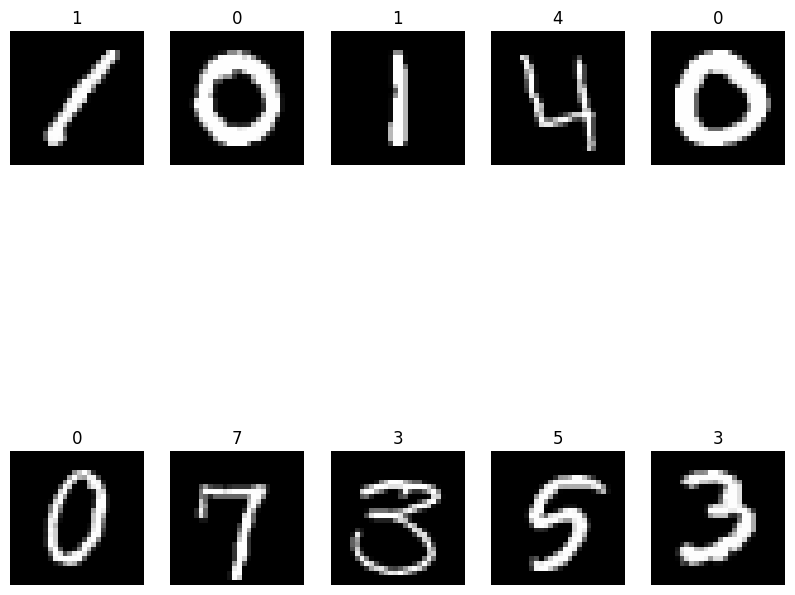

In [9]:
plt.figure(figsize=(10, 10))

for i in range(10):
  plt.subplot(2,5,i+1)
  image = X.iloc[i].values.reshape(28, 28)

  plt.imshow(image, cmap = 'gray')
  plt.title(y.iloc[i])
  plt.axis('off')

plt.show()

In [10]:
X = X / 255.0
test = test / 255.0

In [11]:
# Reset and Reshape Data
# We re-fetch from the original 'test' dataframe to ensure we have the correct data type
X = train.drop('label', axis=1).values.reshape(-1, 28, 28, 1) / 255.0
test_data = pd.read_csv("/content/test.csv").values.reshape(-1, 28, 28, 1) / 255.0
# Update the 'test' variable specifically
test = test_data

In [12]:
# Verification successful. You can now run model.predict(test).

In [13]:
print(X.shape)

(42000, 28, 28, 1)


In [14]:
# Convert Labels
y = to_categorical(y, num_classes = 10)

In [15]:
# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

datagen.fit(X_train)


In [17]:
model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

# Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten
model.add(Flatten())

# Dense Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Dropout
model.add(
    Dropout(0.5)
)

# Output Layer
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

In [18]:
# Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile Model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


In [20]:
# Train Model
history = model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),
    validation_data=(X_val,y_val),
    epochs=15
)

Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.8026 - loss: 0.6046 - val_accuracy: 0.9686 - val_loss: 0.0951
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.9235 - loss: 0.2463 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.9421 - loss: 0.1964 - val_accuracy: 0.9843 - val_loss: 0.0491
Epoch 4/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 45s 86ms/step - accuracy: 0.9541 - loss: 0.1594 - val_accuracy: 0.9875 - val_loss: 0.0396
Epoch 5/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/step - accuracy: 0.9596 - loss: 0.1366 - val_accuracy: 0.9880 - val_loss: 0.0373
Epoch 6/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 44s 84ms/step - accuracy: 0.9632 - loss: 0.1221 - val_accuracy: 0.9892 - val_loss: 0.0322
Epoch 7/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.9663 - loss: 0.1142 - val_accuracy: 0.9896 - val_loss: 0.0297
Epoch 8/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.9685 - loss: 0.1099 - 

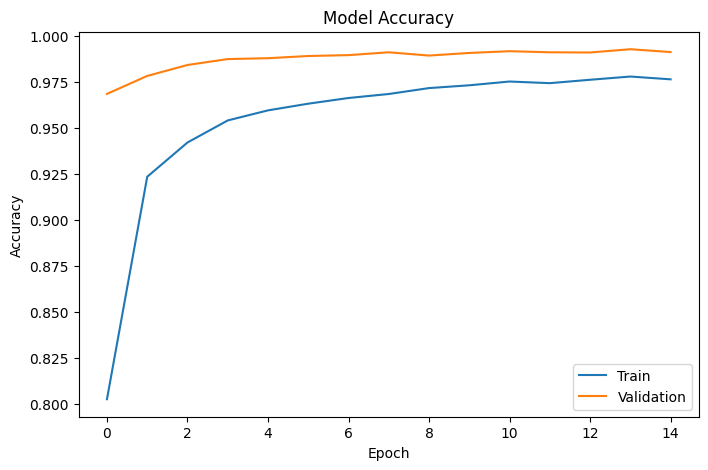

In [21]:
# Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(
    ["Train","Validation"]
)

plt.show()

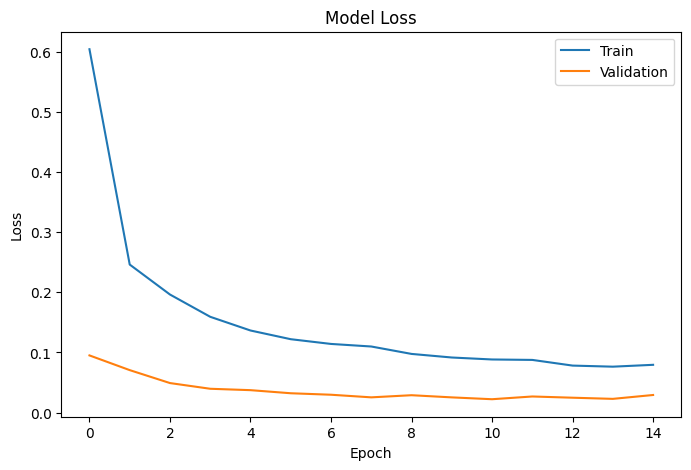

In [22]:
# Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(
    ["Train","Validation"]
)

plt.show()

In [23]:
# Evaluate Model
loss, accuracy = model.evaluate(
    X_val,
    y_val
)

print("Accuracy :", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9913 - loss: 0.0293
Accuracy : 0.9913095235824585


In [24]:
# Predict Data
predictions = model.predict(test)

875/875 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [25]:
print(predictions.shape)

(28000, 10)


In [26]:
# Convert probabilities to labels
predictions = np.argmax(
    predictions,
    axis=1
)

In [27]:
# Create Submission File
submission = pd.DataFrame({
    "ImageId": range(1,len(predictions)+1),
    "Label": predictions
})

In [28]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [29]:
# Save CSV
submission.to_csv(
    "submission.csv",
    index=False
)

In [30]:
# Save Model
model.save("digit_recognizer_model.h5")

In [31]:
from tensorflow.keras.models import load_model

model = load_model(
    "digit_recognizer_model.h5"
)